# W2 relative-entropy flow versus SVGD

This notebook generates `fig:generative-w2-vs-svgd-entropy-flow`.  The target law is a smooth Gaussian mixture
\[
    \beta = \rho_\beta(x)\,\mathrm{d}x,
\]
and the same initial empirical law is evolved by two deterministic particle discretizations of KL descent.

The Wasserstein gradient flow of \(\mathrm{KL}(\alpha\mid\beta)\) is the Fokker--Planck equation
\[
    \partial_t\rho_t = \nabla\cdot\bigl(\rho_t\nabla\log(\rho_t/\rho_\beta)\bigr).
\]
We approximate it by the particle velocity
\[
    \dot X_i(t)=\nabla\log\rho_\beta(X_i(t))-\nabla\log\rho_{\alpha_t,h}(X_i(t)),
\]
where \(\rho_{\alpha_t,h}\) is a sharp Gaussian KDE of the current particles.  The displayed paths are finite-time trajectories, so the blue endpoints should be read as current particle locations rather than fully converged samples from \(\beta\).  SVGD instead uses the RKHS steepest descent direction
\[
    \dot X_i(t)=\frac1n\sum_j
    \Big(k(X_j(t),X_i(t))\nabla\log\rho_\beta(X_j(t))
    +\nabla_{X_j}k(X_j(t),X_i(t))\Big).
\]
The figure shows a farthest-point subsample of representative finite-time trajectories on top of the target density contours, with time encoded from red to blue.

In [ ]:
# --- OT4ML_COLAB_BOOTSTRAP: make this figure notebook runnable standalone in Colab.
from pathlib import Path as _OT4ML_Path
import importlib.util as _OT4ML_importlib_util
import os as _OT4ML_os
import subprocess as _OT4ML_subprocess
import sys as _OT4ML_sys


def _ot4ml_find_repo_root():
    """Locate the OT4ML repository root used by this notebook."""
    here = _OT4ML_Path.cwd().resolve()
    for base in (here, *here.parents):
        if (base / "notebooks-figures" / "figure_style.py").exists():
            return base
        if base.name == "notebooks-figures" and (base / "figure_style.py").exists():
            return base.parent
    return None


def _ot4ml_ensure_package(module_name, package_name):
    """Install a package when the corresponding module is missing."""
    if _OT4ML_importlib_util.find_spec(module_name) is None:
        _OT4ML_subprocess.run(
            [_OT4ML_sys.executable, "-m", "pip", "install", "-q", package_name],
            check=True,
        )


ROOT = _ot4ml_find_repo_root()
if ROOT is None:
    ROOT = _OT4ML_Path("/content/ot4ml") if "google.colab" in _OT4ML_sys.modules else _OT4ML_Path.cwd() / "ot4ml"
    if ROOT.exists() and any(ROOT.iterdir()) and not (ROOT / ".git").exists():
        ROOT = ROOT.with_name(ROOT.name + "-repo")
    if not (ROOT / "notebooks-figures" / "figure_style.py").exists():
        _OT4ML_subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/gpeyre/ot4ml.git", str(ROOT)],
            check=True,
        )

_OT4ML_os.chdir(ROOT)
_figures_path = str(ROOT / "notebooks-figures")
if _figures_path not in _OT4ML_sys.path:
    _OT4ML_sys.path.insert(0, _figures_path)

if "google.colab" in _OT4ML_sys.modules:
    pass

VERBOSE = False

def log(*args, **kwargs):
    """Print diagnostics only when VERBOSE is enabled."""
    if VERBOSE:
        print(*args, **kwargs)


In [1]:
from pathlib import Path
import os
import shutil
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks-figures":
    ROOT = ROOT.parent
elif not (ROOT / "notebooks-figures" / "figure_style.py").exists():
    ROOT = ROOT.parents[0]
FIGROOT = ROOT / "notebooks-figures"
sys.path.insert(0, str(FIGROOT))

from figure_style import BLUE, RED, figure_dir, interp_color, remove_axes, save_pdf, setup_matplotlib

setup_matplotlib()

NAME = "generative-w2-vs-svgd-entropy-flow"
out = figure_dir(NAME)
thumb_dir = FIGROOT / "thumbnails"
thumb_dir.mkdir(exist_ok=True)

# Mirror panels to the arXiv/PDE4ML figure folders.
arxiv_figures = ROOT / "arxiv" / "figures"
pde_figures = ROOT / "PDE4ML" / "figures" / NAME
arxiv_figures.mkdir(parents=True, exist_ok=True)
pde_figures.mkdir(parents=True, exist_ok=True)

## Target mixture and particle flows

The target score is available in closed form for a Gaussian mixture.  The Wasserstein/Fokker--Planck particle closure uses a KDE score for the current law, while SVGD uses only the target score and the RKHS repulsion term.  Both simulations start from the same particles.

In [2]:
rng = np.random.default_rng(20260702)

N = 1000
weights = np.array([0.35, 0.35, 0.30])
means = np.array([
    [0.05, -0.52],
    [0.78,  0.52],
    [1.48, -0.05],
])
sigmas = np.array([0.25, 0.23, 0.27])

init_mean = weights @ means
init_cov = np.array([[0.032, 0.0], [0.0, 0.026]])
X0 = rng.multivariate_normal(init_mean, init_cov, N)


def target_density_score(X):
    """Return density and score of the Gaussian-mixture target."""
    X = np.asarray(X)
    diff = X[:, None, :] - means[None, :, :]
    logp = (
        np.log(weights)[None, :]
        - np.log(2 * np.pi * sigmas**2)[None, :]
        - 0.5 * np.sum(diff**2, axis=2) / (sigmas[None, :] ** 2)
    )
    m = logp.max(axis=1, keepdims=True)
    q = np.exp(logp - m)
    resp = q / q.sum(axis=1, keepdims=True)
    density = np.exp(m[:, 0]) * q.sum(axis=1)
    score = np.sum(resp[:, :, None] * (-diff / (sigmas[None, :, None] ** 2)), axis=1)
    return density, score


def kde_score(X, h):
    """Gaussian KDE score evaluated at the particles themselves."""
    diff = X[:, None, :] - X[None, :, :]
    d2 = np.sum(diff * diff, axis=2)
    K = np.exp(-0.5 * d2 / (h * h))
    den = K.sum(axis=1, keepdims=True)
    return np.sum(K[:, :, None] * (-diff / (h * h)), axis=1) / np.maximum(den, 1e-15)


def svgd_velocity(X, h):
    """RBF-kernel SVGD velocity for the target score."""
    _, score = target_density_score(X)
    diff = X[:, None, :] - X[None, :, :]  # diff[i, j] = X_i - X_j.
    d2 = np.sum(diff * diff, axis=2)
    K = np.exp(-0.5 * d2 / (h * h))
    attraction = K.T @ score / len(X)
    repulsion = np.sum(K[:, :, None] * (-diff / (h * h)), axis=0) / len(X)
    return attraction + repulsion


def clip_velocity(v, q=0.995, multiplier=1.35):
    """Clip only rare outliers so the explicit Euler path remains stable."""
    speed = np.linalg.norm(v, axis=1)
    vmax = np.quantile(speed, q)
    if vmax <= 1e-14:
        return v
    factor = np.minimum(1.0, multiplier * vmax / (speed + 1e-12))
    return v * factor[:, None]


def simulate_w2_kde():
    """Simulate W2 KDE for the time snapshots shown in the figure."""
    X = X0.copy()
    records = []
    h = 0.09
    dt = 0.0045
    steps = 1600
    stride = 14
    for k in range(steps + 1):
        if k % stride == 0:
            records.append(X.copy())
        if k == steps:
            break
        _, target_score = target_density_score(X)
        v = target_score - kde_score(X, h)
        X = X + dt * clip_velocity(v, q=0.995, multiplier=1.4)
    return np.asarray(records)


def simulate_svgd():
    """Simulate SVGD for the time snapshots shown in the figure."""
    X = X0.copy()
    records = []
    h = 0.52
    dt = 0.09
    steps = 370
    stride = 4
    for k in range(steps + 1):
        if k % stride == 0:
            records.append(X.copy())
        if k == steps:
            break
        v = svgd_velocity(X, h)
        X = X + dt * clip_velocity(v, q=0.995, multiplier=1.8)
    return np.asarray(records)


w2_records = simulate_w2_kde()
svgd_records = simulate_svgd()
log("target mean", weights @ means)
log("W2/KDE final mean", w2_records[-1].mean(axis=0))
log("SVGD final mean", svgd_records[-1].mean(axis=0))


target mean [ 0.7345 -0.015 ]
W2/KDE final mean [0.77932125 0.01908433]
SVGD final mean [0.95882274 0.14807885]


## Rendering

The PDFs contain only the graphical panels.  Method labels and interpretation are supplied by LaTeX captions, so the same panels can be reused in the arXiv and MyST builds.

In [3]:
def farthest_point_sample(points, n):
    """Select a farthest-point subset deterministically for reproducible panels."""
    pts = np.asarray(points)
    idx = [int(np.argmin(np.sum((pts - pts.mean(axis=0)) ** 2, axis=1)))]
    dist2 = np.sum((pts - pts[idx[0]]) ** 2, axis=1)
    for _ in range(1, n):
        j = int(np.argmax(dist2))
        idx.append(j)
        dist2 = np.minimum(dist2, np.sum((pts - pts[j]) ** 2, axis=1))
    return np.asarray(idx, dtype=int)


trace_idx = farthest_point_sample(X0, 72)
xlim = (-1.82, 2.08)
ylim = (-1.28, 1.30)

nx, ny = 360, 235
xs = np.linspace(*xlim, nx)
ys = np.linspace(*ylim, ny)
XX, YY = np.meshgrid(xs, ys)
Z, _ = target_density_score(np.column_stack([XX.ravel(), YY.ravel()]))
Z = Z.reshape(YY.shape)
levels = np.quantile(Z[Z > 0], [0.62, 0.76, 0.87, 0.94, 0.978])


def draw_target_context(ax):
    """Draw target context using the common OT4ML visual style."""
    ax.contour(XX, YY, Z, levels=levels, colors="#222222", linewidths=0.46, alpha=0.42, zorder=1)


def draw_trajectories(ax, records, *, linewidth=0.36, alpha=0.46):
    """Draw trajectories using the common OT4ML visual style."""
    draw_target_context(ax)
    trace = records[:, trace_idx, :]
    segments = []
    colors = []
    nt = trace.shape[0]
    for i in range(trace.shape[1]):
        pts = trace[:, i, :]
        for k in range(nt - 1):
            segments.append([pts[k], pts[k + 1]])
            colors.append((*interp_color((k / max(nt - 2, 1)) ** 0.72), alpha))
    ax.add_collection(LineCollection(segments, colors=colors, linewidths=linewidth, zorder=3))
    ax.scatter(trace[0, :, 0], trace[0, :, 1], s=2.8, color=RED, edgecolor="white", linewidth=0.10, zorder=4)
    ax.scatter(trace[-1, :, 0], trace[-1, :, 1], s=2.8, color=BLUE, edgecolor="white", linewidth=0.10, zorder=5)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal")
    remove_axes(ax)


def mirror_pdf(local_path):
    """Evaluate the mirror probability density on the current grid."""
    shutil.copy2(local_path, pde_figures / local_path.name)
    shutil.copy2(local_path, arxiv_figures / f"{NAME}--{local_path.name}")


for method, records in [("w2-kde", w2_records), ("svgd", svgd_records)]:
    fig, ax = plt.subplots(figsize=(3.28, 2.16))
    draw_trajectories(ax, records)
    pdf_path = out / f"{method}-trajectories.pdf"
    save_pdf(fig, pdf_path, pad_inches=0.006)
    mirror_pdf(pdf_path)
    plt.close(fig)

# Compact gallery thumbnail for the notebook README and MyST preview.
fig, axs = plt.subplots(1, 2, figsize=(6.9, 2.16), gridspec_kw={"wspace": 0.035})
for ax, records in zip(axs, [w2_records, svgd_records]):
    draw_trajectories(ax, records, linewidth=0.38, alpha=0.50)
fig.savefig(thumb_dir / f"{NAME}.png", dpi=230, bbox_inches="tight", pad_inches=0.016)
plt.close(fig)

log(f"Wrote panels to {out}")
log(f"Wrote thumbnail to {thumb_dir / (NAME + '.png')}")


Wrote panels to /Users/gpeyre/Dropbox/github/ot4ml/OT4ML/figures/generative-w2-vs-svgd-entropy-flow
Wrote thumbnail to /Users/gpeyre/Dropbox/github/ot4ml/notebooks-figures/thumbnails/generative-w2-vs-svgd-entropy-flow.png


## Figure preview

The output below embeds the generated thumbnail so the notebook renders directly on GitHub.

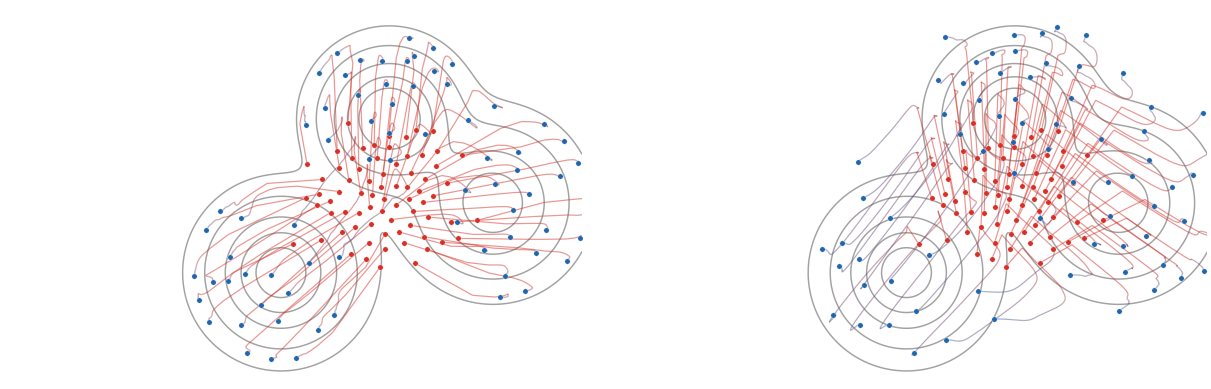

In [4]:
from IPython.display import Image as IPImage, display

_thumb = Path("thumbnails/generative-w2-vs-svgd-entropy-flow.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/generative-w2-vs-svgd-entropy-flow.png")
display(IPImage(filename=str(_thumb)))